Here we are testing the impact of the model overfitting on SHAP(SHapley Additive exPlanations) explanations

#### import required libraries

In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

#### download the data - california housing price  from kaggle

In [2]:
import kagglehub
# Download latest version
path = kagglehub.dataset_download("camnugent/california-housing-prices")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/california-housing-prices


#### loading the data and performing some eda

In [3]:
! ls -lrt /kaggle/input/california-housing-prices

total 1392
-rw-r--r-- 1 1000 1000 1423529 Jul 26 18:27 housing.csv


In [4]:
df = pd.read_csv(os.path.join(path, 'housing.csv'))
df.shape

(20640, 10)

In [5]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [6]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [7]:
df.total_bedrooms.fillna(0, inplace=True)

In [8]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,532.476211,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,422.678333,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,0.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,292.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,431.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,643.250000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [9]:
num_cols = df.describe().columns.to_list()
num_cols

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'median_house_value']

In [10]:
cat_cols = list(set(df.columns) - set(df.describe().columns))
cat_cols

['ocean_proximity']

In [11]:
def hist_plot(df, cols, n_bins=20, fig_size=(10, 7), sp_rows=2, sp_cols=2):
    if len(cols) > sp_rows * sp_cols:
      raise Exception( f'Count of columns:{len(cols)} more the product of rows and columns:{sp_rows * sp_cols}')
    fig, ax = plt.subplots(nrows=sp_rows, ncols=sp_cols, figsize=fig_size)
    ax_list = ax.flatten()
    for i, col in enumerate(cols):
        sns.histplot(data=df, x=col, kde=True, ax=ax_list[i])
    plt.tight_layout()
    plt.show()

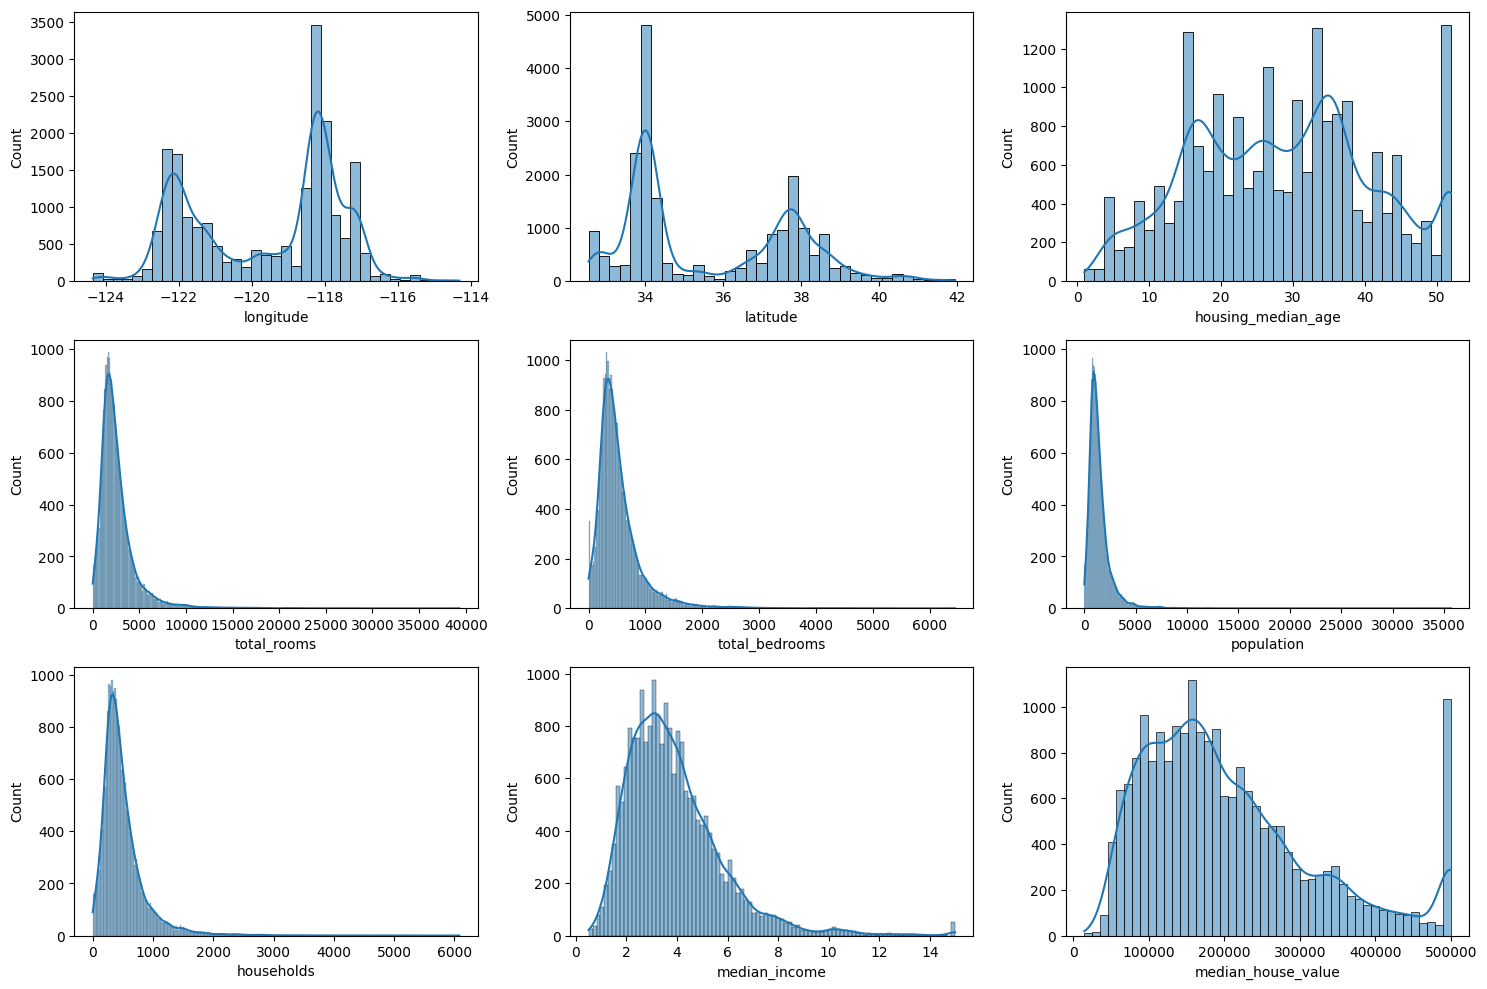

In [12]:
hist_plot(df, num_cols, sp_rows=3, sp_cols=3, fig_size=(15, 10))

In [13]:
def scatter_plot(df, cols, fig_size=(10, 7)):
    from itertools import combinations
    graphs = list(combinations(cols, 2))
    n_graphs = len(graphs)
    print(f'plot count:{n_graphs}')
    sp_rows = int(np.ceil(np.sqrt(n_graphs)))
    sp_cols = int(np.ceil(n_graphs / sp_rows))
    fig, ax = plt.subplots(nrows=sp_rows, ncols=sp_cols, figsize=fig_size)
    axes = ax.flatten()
    for idx, graph in enumerate(graphs):
      sns.scatterplot(data=df, x=graph[0], y=graph[1], ax=axes[idx])
    plt.tight_layout()
    plt.show()

plot count:36


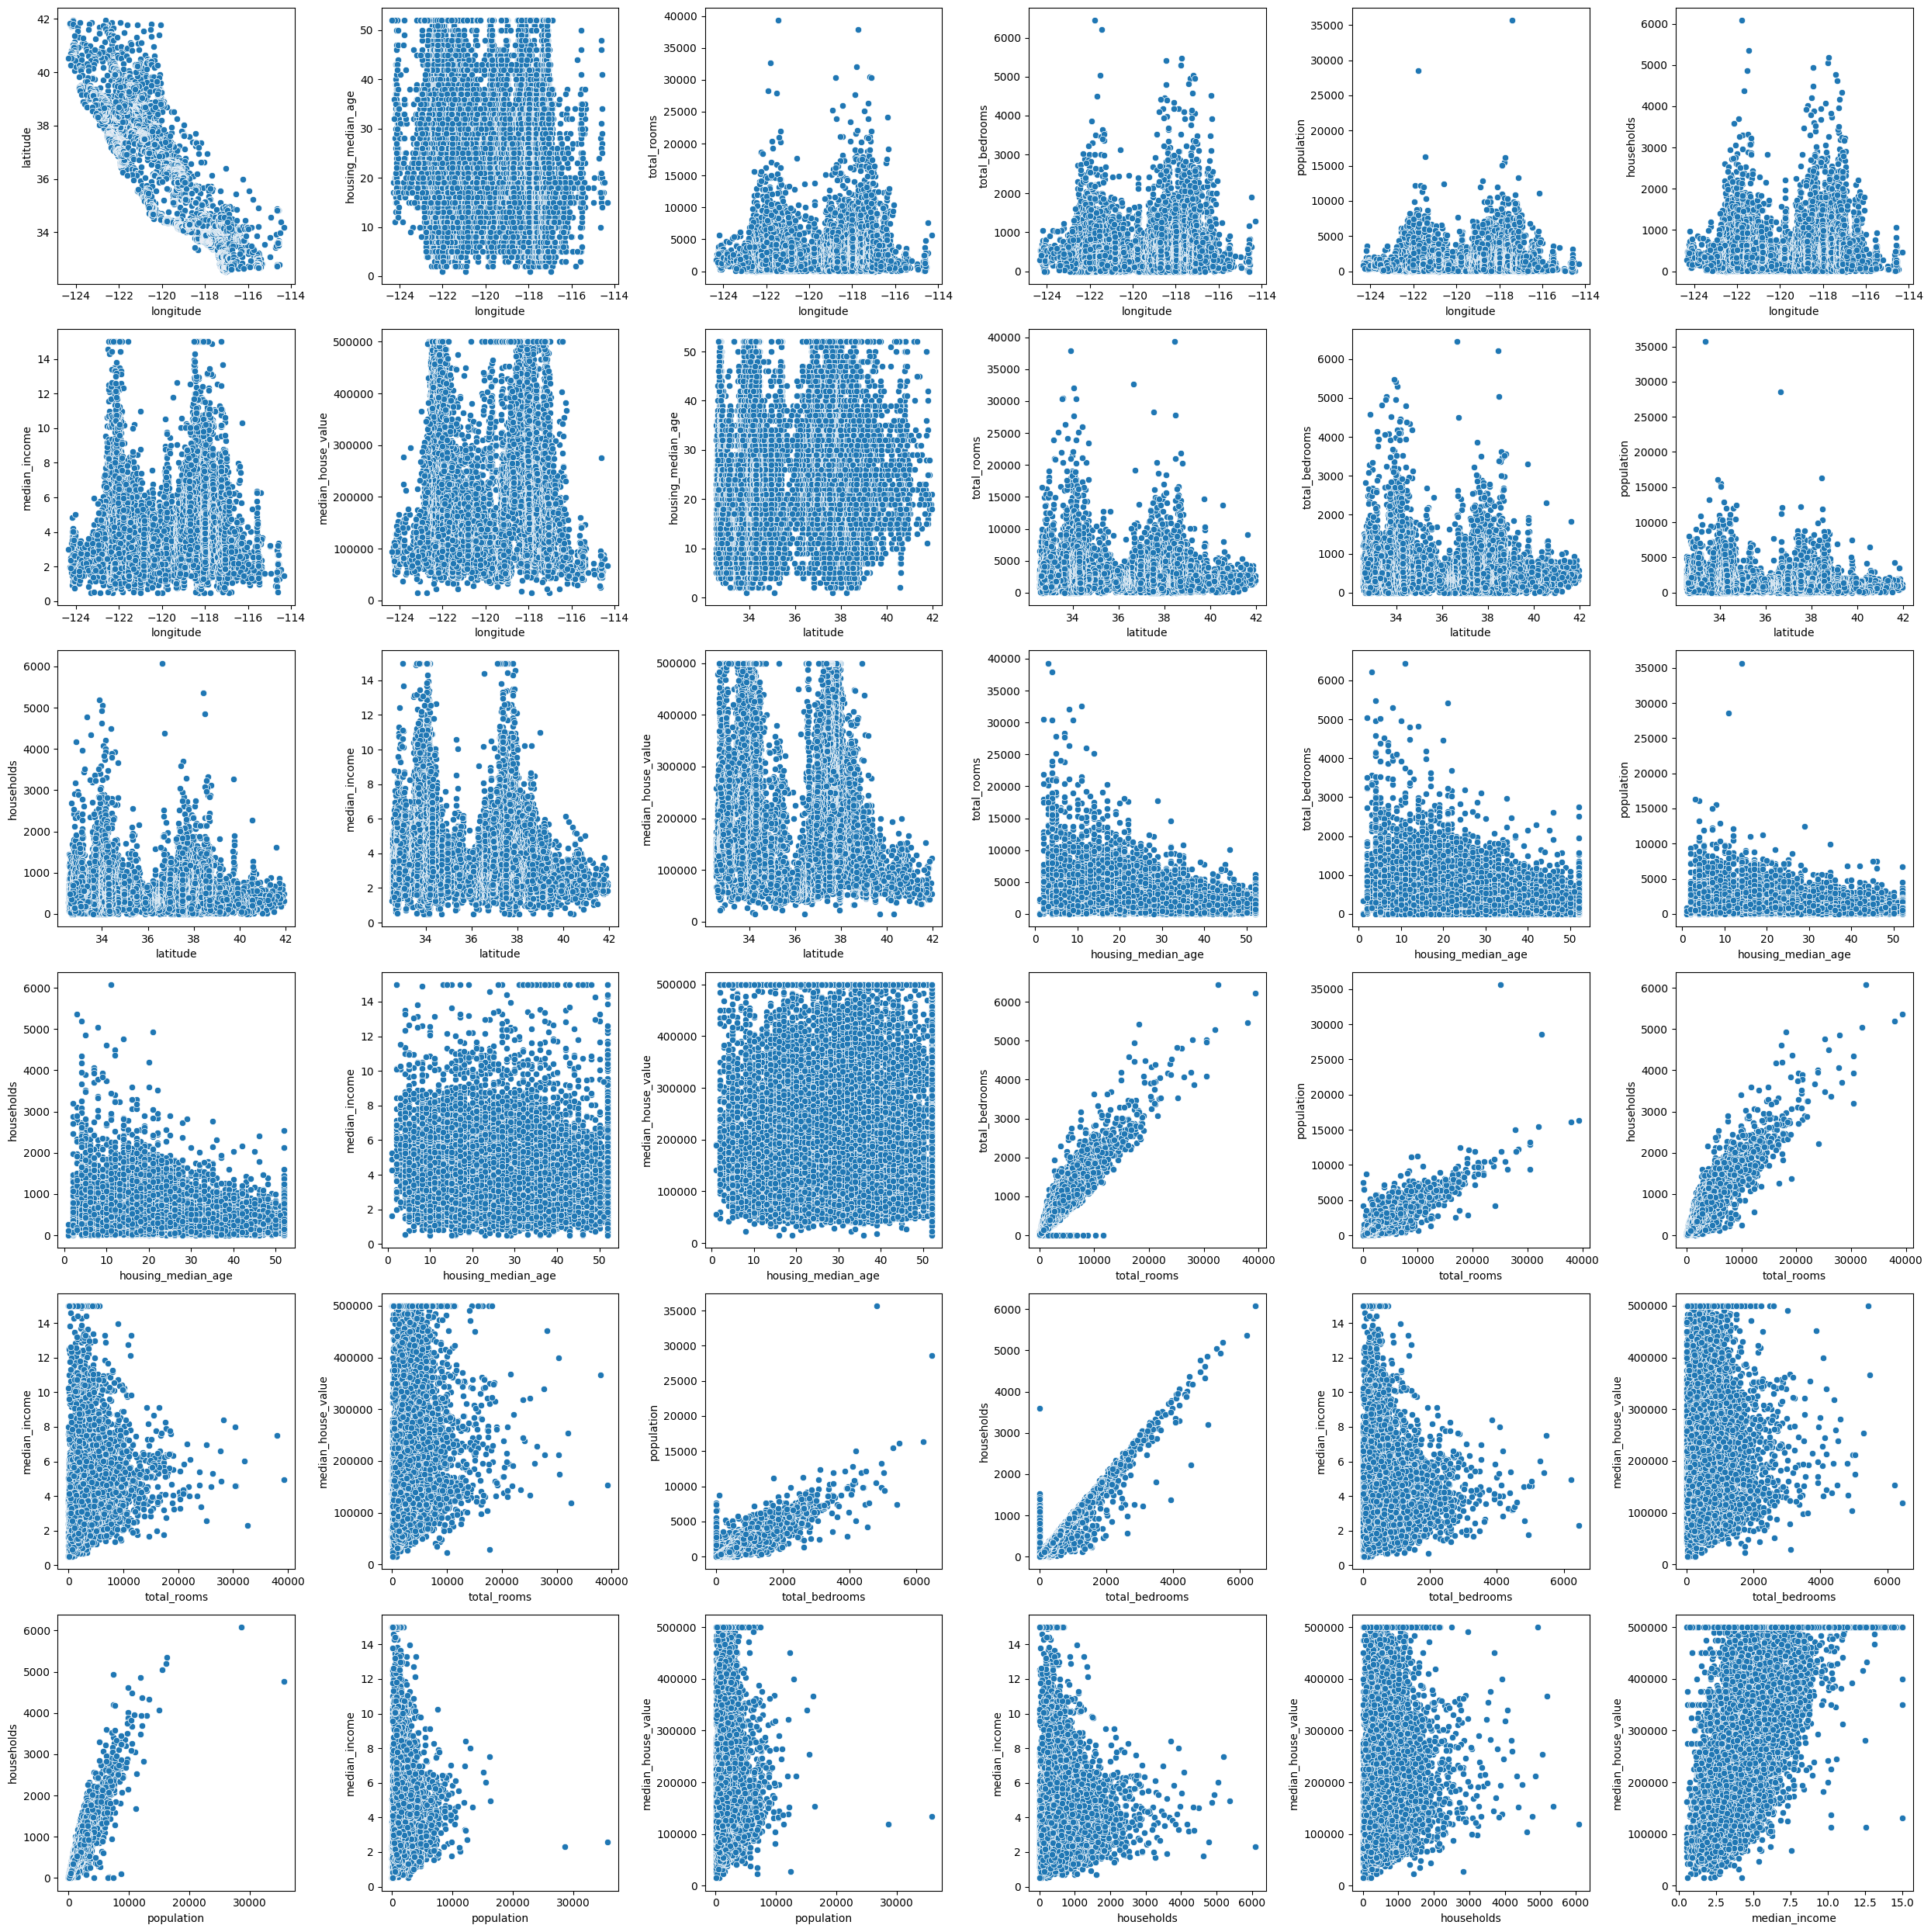

In [14]:
scatter_plot(df, num_cols, fig_size=(25, 25))

<Axes: >

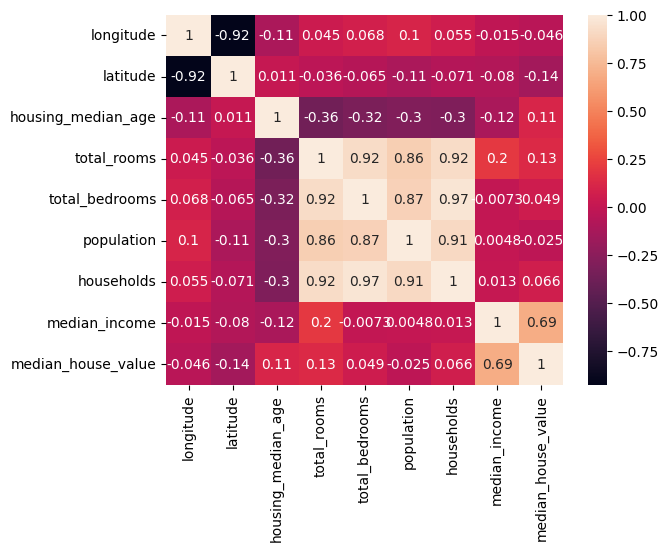

In [15]:
sns.heatmap(df[num_cols].corr(), annot=True)

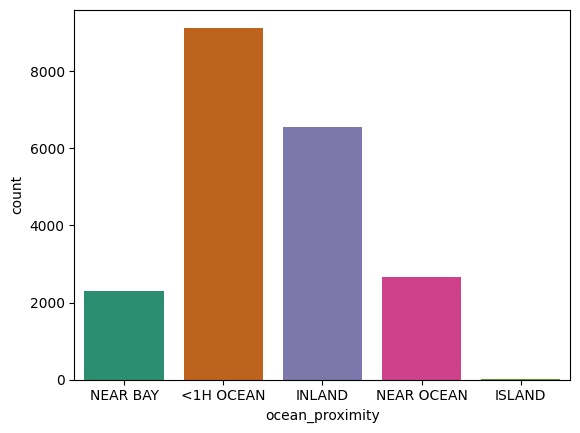

In [16]:
sns.countplot(data=df, x='ocean_proximity', palette='Dark2', stat='count')
plt.show()

In [17]:
def violin_plot(df, cat_cols, num_cols, figsize=(10, 7)):
    fig, ax = plt.subplots(nrows=len(cat_cols), ncols=len(num_cols), figsize=figsize)
    axes = ax.flatten()
    idx = 0
    for _, cat_col in enumerate(cat_cols):
        for _, num_col in enumerate(num_cols):
            sns_ax = sns.violinplot(data=df, x=cat_col, y=num_col, ax=axes[idx], palette='Dark2')
            sns_ax.set_xticklabels(labels=sns_ax.get_xticklabels(), rotation=45)

            idx += 1
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

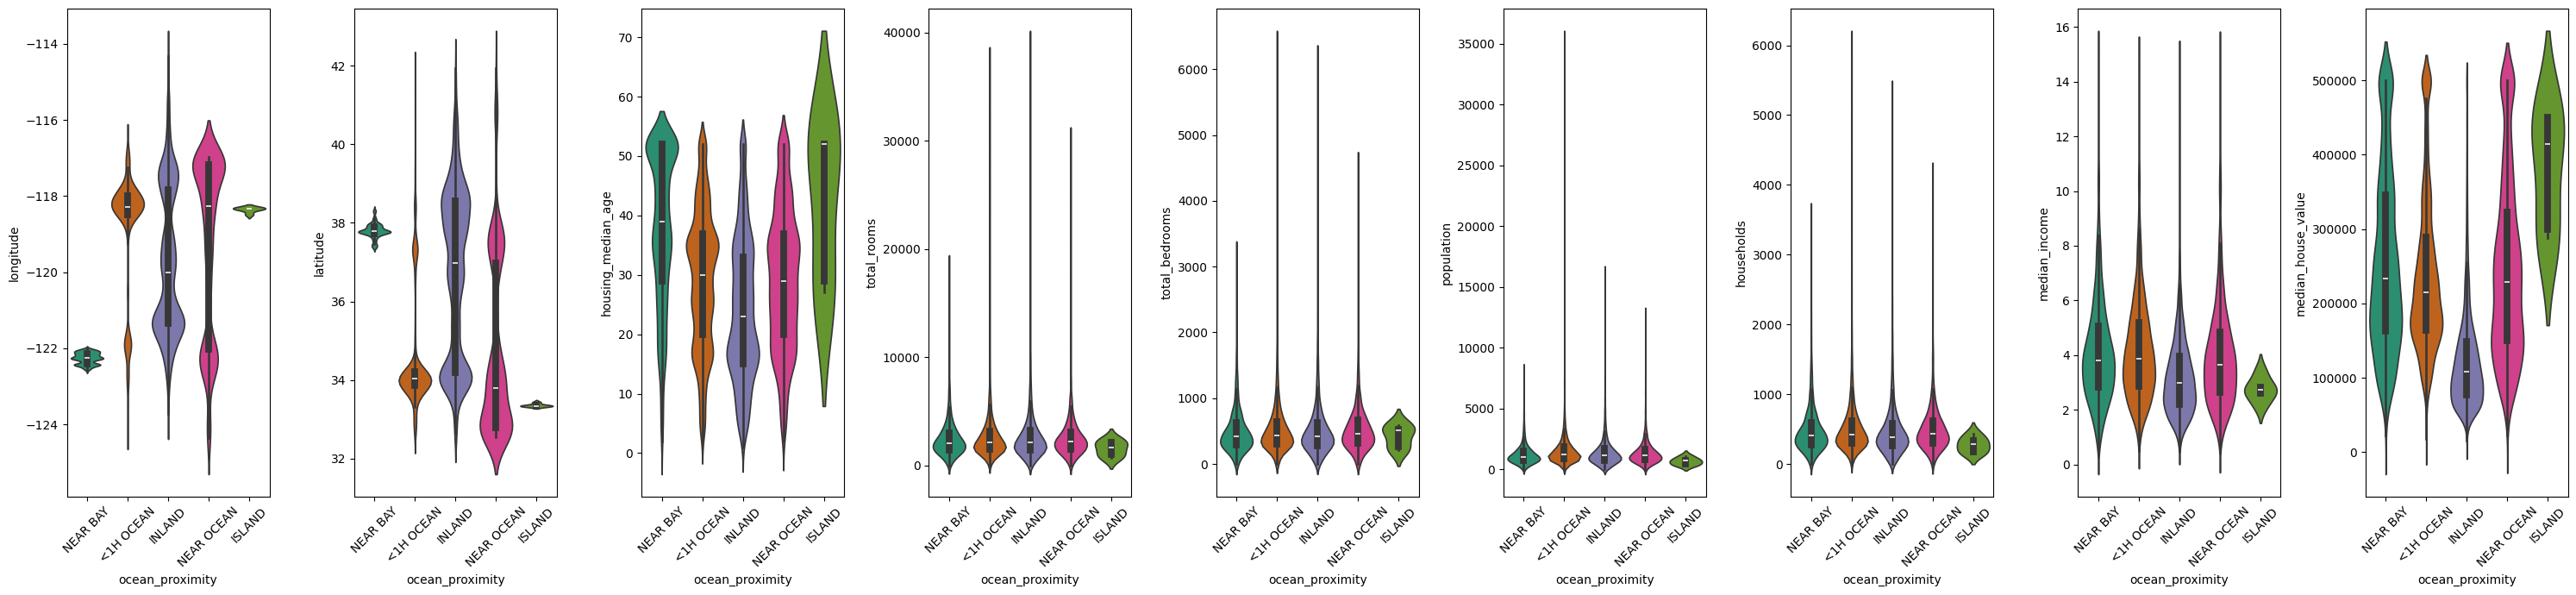

In [18]:
violin_plot(df, cat_cols, num_cols, figsize=(30, 7))

In [19]:
def box_plot(df, cat_cols, num_cols, figsize=(10, 7)):
    fig, ax = plt.subplots(nrows=len(cat_cols), ncols=len(num_cols), figsize=figsize)
    axes = ax.flatten()
    idx = 0
    for _, cat_col in enumerate(cat_cols):
        for _, num_col in enumerate(num_cols):
            sns_ax = sns.boxplot(data=df, x=cat_col, y=num_col, ax=axes[idx], palette='Dark2')
            sns_ax.set_xticklabels(labels=sns_ax.get_xticklabels(), rotation=45)

            idx += 1
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

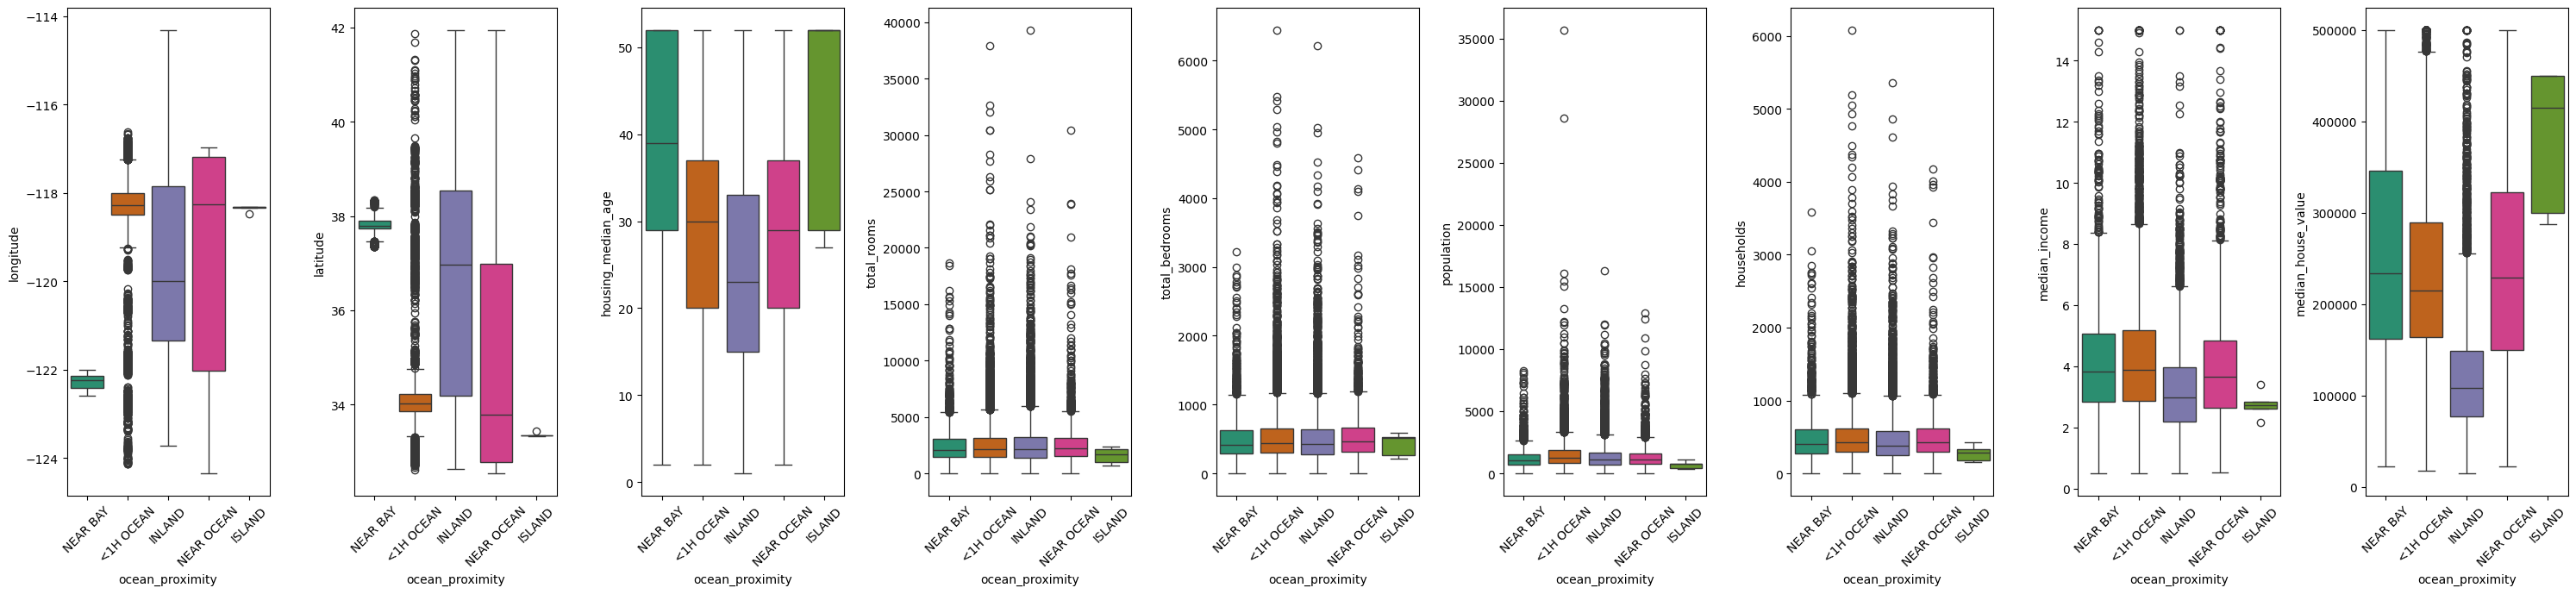

In [20]:
box_plot(df, cat_cols, num_cols, figsize=(30, 7))

#### Make test and train set

In [21]:
from random import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler

random_state = 42


ordinal_encoder = OrdinalEncoder()
ordinal_encoder.fit(df[['ocean_proximity']])


df_train, df_test = train_test_split(df, test_size=0.2, random_state=random_state, stratify=df['ocean_proximity'])
df_train.shape, df_test.shape

((16512, 10), (4128, 10))

In [22]:
df_train['ocean_proximity'] = ordinal_encoder.transform(df_train[['ocean_proximity']])
df_test['ocean_proximity'] = ordinal_encoder.transform(df_test[['ocean_proximity']])

In [23]:
df_train_processed = df_train.copy()
df_test_processed = df_test.copy()

In [24]:
min_max_scalers = dict()

for col in num_cols:
  scaler = MinMaxScaler()
  df_train_processed[col] = scaler.fit_transform(df_train_processed[[col]])
  df_test_processed[col] = scaler.transform(df_test_processed[[col]])
  min_max_scalers[col] =  scaler

In [25]:
X_train = df_train_processed.drop(['median_house_value'], axis=1)
y_train = df_train_processed['median_house_value']

X_test = df_test_processed.drop(['median_house_value'], axis=1)
y_test = df_test_processed['median_house_value']

#### Using DT to make prediction

In [26]:
# lib imports
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

from rich.table import Table
from rich.console import Console

##### letting it overfit

In [27]:
dt_overfit = DecisionTreeRegressor(random_state=random_state)
dt_overfit.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [28]:
y_pred_train = dt_overfit.predict(X_train)
y_pred_test = dt_overfit.predict(X_test)

In [29]:
console = Console()
metrics_table = Table(title="Metrics Value",show_lines=True)
metrics_table.add_column("Name", justify="right", style="cyan")
metrics_table.add_column("Train", justify="left", style="green")
metrics_table.add_column("Test", justify="left", style="blue")

metrics_table.add_row("RMSE", str(np.round(np.sqrt(mean_squared_error(y_train, y_pred_train)), 2)), str(np.round(np.sqrt(mean_squared_error(y_test, y_pred_test)),2)) )
metrics_table.add_row("R2", str(np.round(r2_score(y_train, y_pred_train),2)), str(np.round(r2_score(y_test, y_pred_test),2)) )

console.print(metrics_table)

     Metrics Value     
┏━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Name ┃ Train ┃ Test ┃
┡━━━━━━╇━━━━━━━╇━━━━━━┩
│ RMSE │ 0.0   │ 0.14 │
├──────┼───────┼──────┤
│   R2 │ 1.0   │ 0.65 │
└──────┴───────┴──────┘

##### not overfitting

In [30]:
param_grid = {
    'max_depth' : range(3, 35, 2),
    'min_samples_leaf' : range(1, 10, 2),
    'min_samples_split' : range(2, 10, 2)
}

search = GridSearchCV(DecisionTreeRegressor(random_state=random_state), param_grid=param_grid, scoring='r2', cv=5, verbose=2)
search.fit(X_train, y_train)

Fitting 5 folds for each of 320 candidates, totalling 1600 fits
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2; total time=   0.1s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2; total time=   0.1s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2; total time=   0.1s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2; total time=   0.1s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2; total time=   0.1s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=4; total time=   0.1s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=4; total time=   0.1s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=4; total time=   0.1s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=4; total time=   0.1s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=4; total time=   0.1s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=6; total time=   0.1s
[CV] END max_depth=3, min_samples_

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42),
             param_grid={'max_depth': range(3, 35, 2),
                         'min_samples_leaf': range(1, 10, 2),
                         'min_samples_split': range(2, 10, 2)},
             scoring='r2', verbose=2)

In [31]:
search.best_params_

{'max_depth': 13, 'min_samples_leaf': 9, 'min_samples_split': 2}

In [32]:
search.best_score_

np.float64(0.7376508113731669)

In [33]:
param_grid_1 = {
    # 'max_depth' : range(3, 35, 2),
    'min_samples_leaf' : range(15, 25, 2),
    'min_samples_split' : range(2, 10, 2)
}

search_1 = GridSearchCV(DecisionTreeRegressor(random_state=random_state, max_depth=13), param_grid=param_grid_1, scoring='r2', cv=5, verbose=2)
search_1.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END ...........min_samples_leaf=15, min_samples_split=2; total time=   0.1s
[CV] END ...........min_samples_leaf=15, min_samples_split=2; total time=   0.1s
[CV] END ...........min_samples_leaf=15, min_samples_split=2; total time=   0.1s
[CV] END ...........min_samples_leaf=15, min_samples_split=2; total time=   0.1s
[CV] END ...........min_samples_leaf=15, min_samples_split=2; total time=   0.1s
[CV] END ...........min_samples_leaf=15, min_samples_split=4; total time=   0.1s
[CV] END ...........min_samples_leaf=15, min_samples_split=4; total time=   0.1s
[CV] END ...........min_samples_leaf=15, min_samples_split=4; total time=   0.1s
[CV] END ...........min_samples_leaf=15, min_samples_split=4; total time=   0.1s
[CV] END ...........min_samples_leaf=15, min_samples_split=4; total time=   0.1s
[CV] END ...........min_samples_leaf=15, min_samples_split=6; total time=   0.1s
[CV] END ...........min_samples_leaf=15, min_sa

GridSearchCV(cv=5,
             estimator=DecisionTreeRegressor(max_depth=13, random_state=42),
             param_grid={'min_samples_leaf': range(15, 25, 2),
                         'min_samples_split': range(2, 10, 2)},
             scoring='r2', verbose=2)

In [34]:
search_1.best_params_

{'min_samples_leaf': 15, 'min_samples_split': 2}

In [35]:
search_1.best_score_

np.float64(0.7415782889910958)

In [36]:
dt_not_overfit = search_1.best_estimator_

In [37]:
y_pred_train_1 = dt_not_overfit.predict(X_train)
y_pred_test_1 = dt_not_overfit.predict(X_test)

In [38]:
console = Console()
metrics_table = Table(title="Metrics Value",show_lines=True)
metrics_table.add_column("Name", justify="right", style="cyan")
metrics_table.add_column("Train", justify="left", style="green")
metrics_table.add_column("Test", justify="left", style="blue")

metrics_table.add_row("RMSE", str(np.round(np.sqrt(mean_squared_error(y_train, y_pred_train_1)), 2)), str(np.round(np.sqrt(mean_squared_error(y_test, y_pred_test_1)),2)) )
metrics_table.add_row("R2", str(np.round(r2_score(y_train, y_pred_train_1),2)), str(np.round(r2_score(y_test, y_pred_test_1),2)) )

console.print(metrics_table)

     Metrics Value     
┏━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Name ┃ Train ┃ Test ┃
┡━━━━━━╇━━━━━━━╇━━━━━━┩
│ RMSE │ 0.1   │ 0.12 │
├──────┼───────┼──────┤
│   R2 │ 0.83  │ 0.74 │
└──────┴───────┴──────┘

#### Testing with RandomForest

In [39]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV, HalvingRandomSearchCV


In [40]:
param_grid_2 = {
    'n_estimators' : range(50, 150, 10),
    'max_depth' : range(10, 20, 2),
    'min_samples_leaf' : range(10, 20, 2),
    'min_samples_split' : range(2, 10, 2)
}

# search_2 = HalvingGridSearchCV(RandomForestRegressor(random_state=random_state), param_grid=param_grid_2, scoring='r2', cv=5, verbose=2, n_jobs=-1)
search_2 = HalvingRandomSearchCV(RandomForestRegressor(random_state=random_state), param_distributions =param_grid_2, scoring='r2', cv=5, verbose=2, n_jobs=-1)
search_2.fit(X_train, y_train)

n_iterations: 7
n_required_iterations: 7
n_possible_iterations: 7
min_resources_: 10
max_resources_: 16512
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 1000
n_resources: 10
Fitting 5 folds for each of 1000 candidates, totalling 5000 fits
----------
iter: 1
n_candidates: 334
n_resources: 30
Fitting 5 folds for each of 334 candidates, totalling 1670 fits
----------
iter: 2
n_candidates: 112
n_resources: 90
Fitting 5 folds for each of 112 candidates, totalling 560 fits
----------
iter: 3
n_candidates: 38
n_resources: 270
Fitting 5 folds for each of 38 candidates, totalling 190 fits
----------
iter: 4
n_candidates: 13
n_resources: 810
Fitting 5 folds for each of 13 candidates, totalling 65 fits
----------
iter: 5
n_candidates: 5
n_resources: 2430
Fitting 5 folds for each of 5 candidates, totalling 25 fits
----------
iter: 6
n_candidates: 2
n_resources: 7290
Fitting 5 folds for each of 2 candidates, totalling 10 fits


HalvingRandomSearchCV(estimator=RandomForestRegressor(random_state=42),
                      n_jobs=-1,
                      param_distributions={'max_depth': range(10, 20, 2),
                                           'min_samples_leaf': range(10, 20, 2),
                                           'min_samples_split': range(2, 10, 2),
                                           'n_estimators': range(50, 150, 10)},
                      scoring='r2', verbose=2)

In [41]:
search_2

HalvingRandomSearchCV(estimator=RandomForestRegressor(random_state=42),
                      n_jobs=-1,
                      param_distributions={'max_depth': range(10, 20, 2),
                                           'min_samples_leaf': range(10, 20, 2),
                                           'min_samples_split': range(2, 10, 2),
                                           'n_estimators': range(50, 150, 10)},
                      scoring='r2', verbose=2)

In [42]:
search_2.best_params_

{'n_estimators': 60,
 'min_samples_split': 8,
 'min_samples_leaf': 10,
 'max_depth': 14}

In [43]:
search_2.best_estimator_

RandomForestRegressor(max_depth=14, min_samples_leaf=10, min_samples_split=8,
                      n_estimators=60, random_state=42)

In [44]:
best_ensemble_model = search_2.best_estimator_

In [45]:
y_pred_train_2 = best_ensemble_model.predict(X_train)
y_pred_test_2 = best_ensemble_model.predict(X_test)

In [46]:
console = Console()
metrics_table = Table(title="Metrics Value",show_lines=True)
metrics_table.add_column("Name", justify="right", style="cyan")
metrics_table.add_column("Train", justify="left", style="green")
metrics_table.add_column("Test", justify="left", style="blue")

metrics_table.add_row("RMSE", str(np.round(np.sqrt(mean_squared_error(y_train, y_pred_train_2)), 2)), str(np.round(np.sqrt(mean_squared_error(y_test, y_pred_test_2)),2)) )
metrics_table.add_row("R2", str(np.round(r2_score(y_train, y_pred_train_2),2)), str(np.round(r2_score(y_test, y_pred_test_2),2)) )

console.print(metrics_table)

     Metrics Value     
┏━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Name ┃ Train ┃ Test ┃
┡━━━━━━╇━━━━━━━╇━━━━━━┩
│ RMSE │ 0.09  │ 0.11 │
├──────┼───────┼──────┤
│   R2 │ 0.87  │ 0.81 │
└──────┴───────┴──────┘

#### Trying shapely explanation

In [47]:
# import library

In [48]:
import shap

In [91]:
tree_explainer_overfit = shap.TreeExplainer(dt_overfit)
shap_values = pd.DataFrame(tree_explainer_overfit.shap_values(X_train), columns=X_train.columns)
mean_shap_values = np.mean(shap_values, axis=0)
mean_shap_values

,0
longitude,0.000939
latitude,0.004796
housing_median_age,0.004081
total_rooms,-0.000276
total_bedrooms,0.000262
population,0.001082
households,0.000584
median_income,-0.006694
ocean_proximity,-0.004776


In [92]:
tree_explainer_not_overfit = shap.TreeExplainer(dt_not_overfit)
shap_values_1 = pd.DataFrame(tree_explainer_not_overfit.shap_values(X_train), columns=X_train.columns)
mean_shap_values_1 = np.mean(shap_values_1, axis=0)
mean_shap_values_1

,0
longitude,0.002975
latitude,0.004364
housing_median_age,0.002864
total_rooms,-0.000280
total_bedrooms,-0.000766
population,0.000600
households,0.000272
median_income,-0.007135
ocean_proximity,-0.002893


In [93]:
tree_explainer_best_ensemble = shap.TreeExplainer(best_ensemble_model)
shap_values_2 = pd.DataFrame(tree_explainer_best_ensemble.shap_values(X_train), columns=X_train.columns)
mean_shap_values_2 = np.mean(shap_values_2, axis=0)
mean_shap_values_2

,0
longitude,0.005524
latitude,0.001924
housing_median_age,0.001298
total_rooms,-0.000437
total_bedrooms,-0.000636
population,0.001123
households,-0.000066
median_income,-0.006203
ocean_proximity,-0.002813


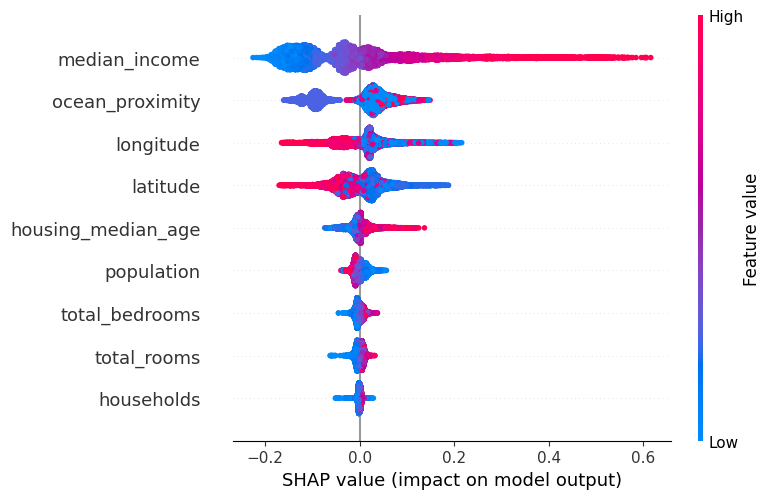

In [94]:
shap.summary_plot(shap_values_2.values, X_train,)

In [96]:
shap_summary_mean = pd.DataFrame(data = {
    'overfitted_model': mean_shap_values,
    'not_overfitted_model': mean_shap_values_1,
    'best_ensemble_model': mean_shap_values_2
},
index = X_train.columns

)
shap_summary_mean

,overfitted_model,not_overfitted_model,best_ensemble_model
longitude,0.000939,0.002975,0.005524
latitude,0.004796,0.004364,0.001924
housing_median_age,0.004081,0.002864,0.001298
total_rooms,-0.000276,-0.000280,-0.000437
total_bedrooms,0.000262,-0.000766,-0.000636
population,0.001082,0.000600,0.001123
households,0.000584,0.000272,-0.000066
median_income,-0.006694,-0.007135,-0.006203
ocean_proximity,-0.004776,-0.002893,-0.002813


**These graphs show that the explainability of the model will change with the quality of the model.**

<Axes: >

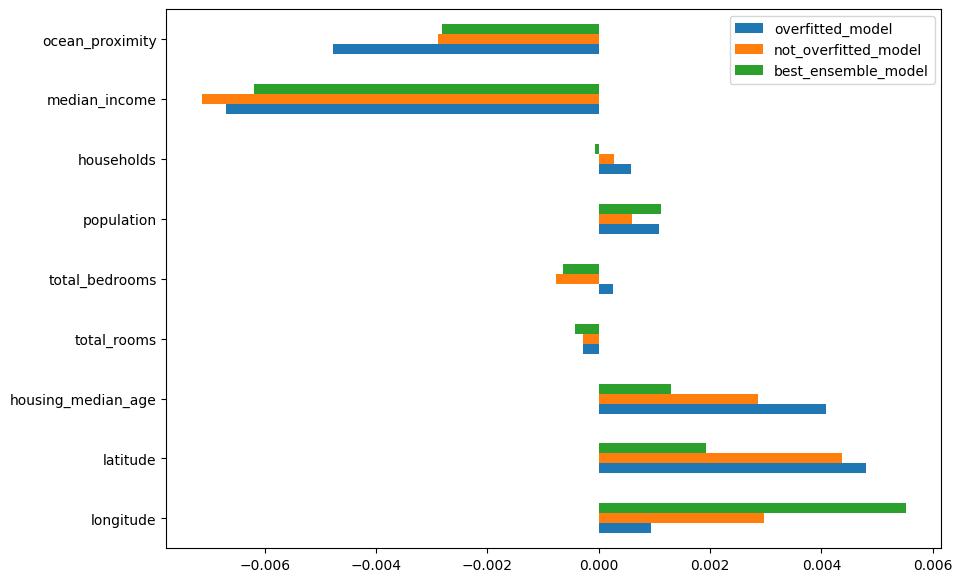

In [97]:
shap_summary_mean.plot(kind='barh', figsize=(10, 7))

<Axes: >

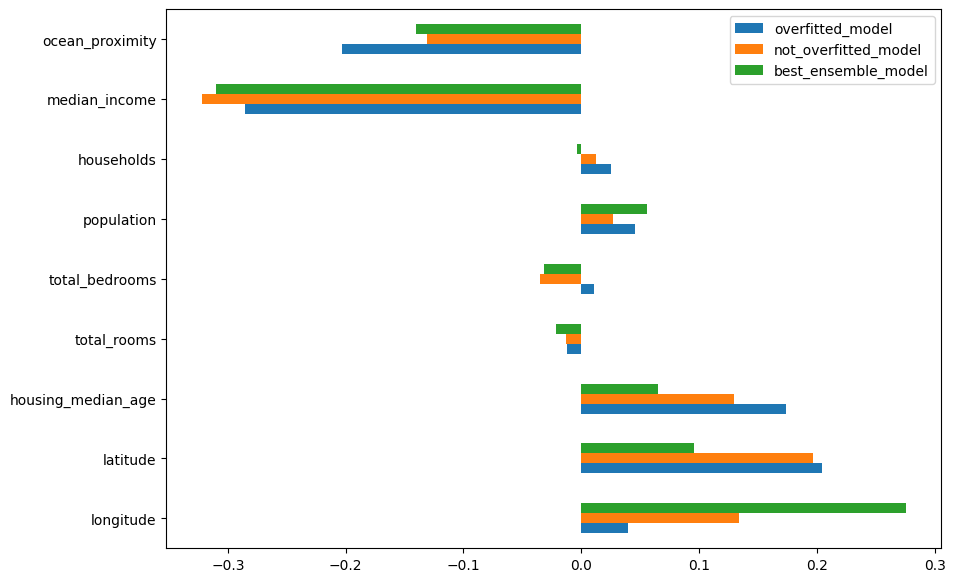

In [98]:
shap_summary_mean.apply(lambda x: x/sum(abs(x))).plot(kind='barh', figsize=(10, 7))

In [99]:
shap_summary_median = pd.DataFrame(data = {
    'overfitted_model': np.median(shap_values, axis=0),
    'not_overfitted_model': np.median(shap_values_1, axis=0),
    'best_ensemble_model': np.median(shap_values_2, axis=0)
},
index = X_train.columns

)
shap_summary_median

,overfitted_model,not_overfitted_model,best_ensemble_model
longitude,0.010071,0.012108,0.014910
latitude,0.005098,0.005181,0.005234
housing_median_age,0.003745,0.003471,-0.000369
total_rooms,-0.000142,-0.000905,-0.000321
total_bedrooms,-0.000637,-0.002068,-0.001400
population,-0.001341,-0.001237,-0.000693
households,0.001045,0.000628,-0.000091
median_income,-0.028538,-0.029232,-0.029977
ocean_proximity,0.019882,0.021381,0.023479


<Axes: >

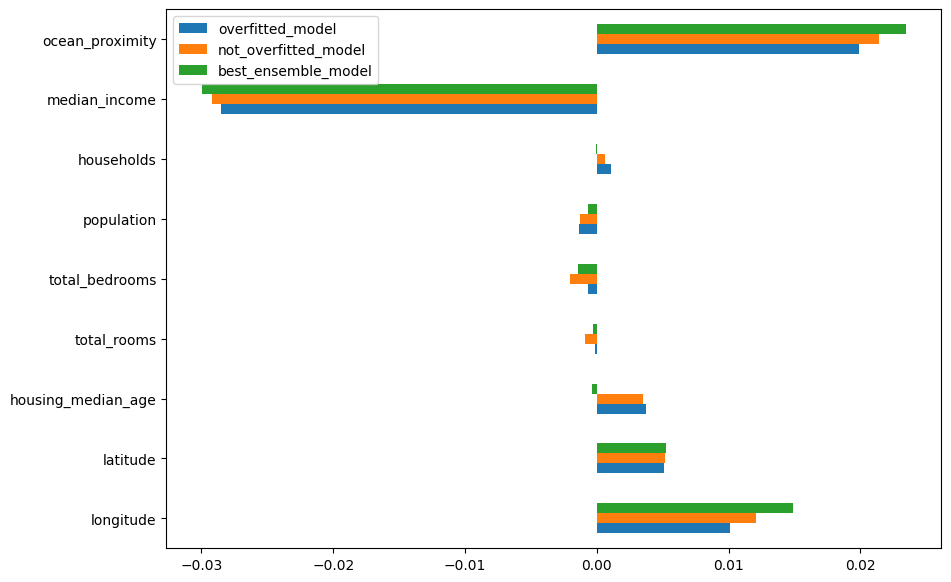

In [100]:
shap_summary_median.plot(kind='barh', figsize=(10, 7))

<Axes: >

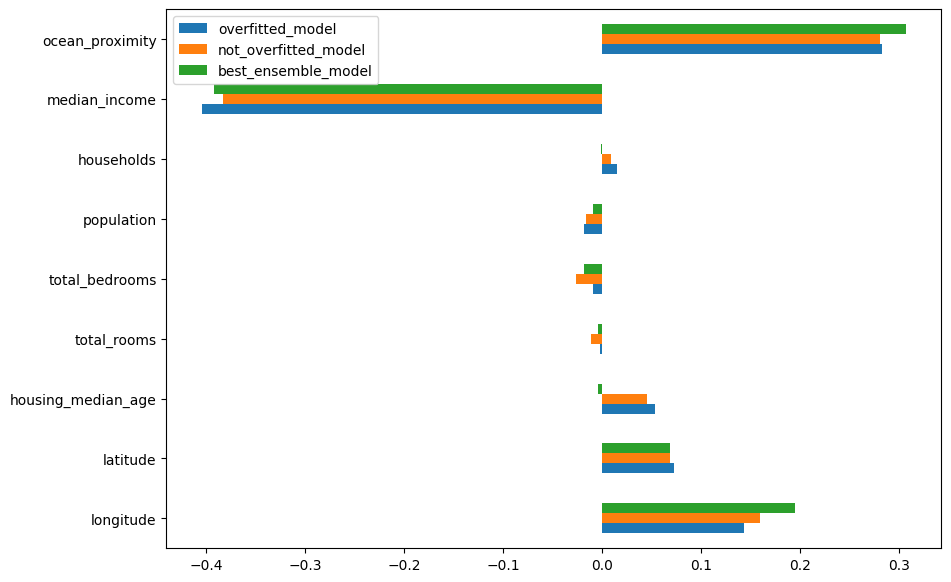

In [101]:
shap_summary_median.apply(lambda x: x/np.sum(abs(x), axis=0)).plot(kind='barh', figsize=(10, 7))

#### Trying Ridge regression

In [102]:
from sklearn.linear_model import Ridge, Lasso

In [103]:
ridge_model = Ridge(random_state=random_state)

param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

search_3 = GridSearchCV(ridge_model, param_grid=param_grid, scoring='r2', cv=5, verbose=2)
search_3.fit(X_train, y_train)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END .........................................alpha=0.01; total time=   0.0s
[CV] END .........................................alpha=0.01; total time=   0.0s
[CV] END .........................................alpha=0.01; total time=   0.0s
[CV] END .........................................alpha=0.01; total time=   0.0s
[CV] END .........................................alpha=0.01; total time=   0.0s
[CV] END ..........................................alpha=0.1; total time=   0.0s
[CV] END ........................................

GridSearchCV(cv=5, estimator=Ridge(random_state=42),
             param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]},
             scoring='r2', verbose=2)

In [104]:
search_3.best_params_

{'alpha': 0.1}

In [105]:
search_3.best_score_

np.float64(0.6301486416466671)

In [106]:
y_pred_train_3 = search_3.best_estimator_.predict(X_train)
y_pred_test_3 = search_3.best_estimator_.predict(X_test)
console = Console()
metrics_table = Table(title="Metrics Value",show_lines=True)
metrics_table.add_column("Name", justify="right", style="cyan")
metrics_table.add_column("Train", justify="left", style="green")
metrics_table.add_column("Test", justify="left", style="blue")

metrics_table.add_row("RMSE", str(np.round(np.sqrt(mean_squared_error(y_train, y_pred_train_3)), 2)), str(np.round(np.sqrt(mean_squared_error(y_test, y_pred_test_3)),2)) )
metrics_table.add_row("R2", str(np.round(r2_score(y_train, y_pred_train_3),2)), str(np.round(r2_score(y_test, y_pred_test_3),2)) )

console.print(metrics_table)

     Metrics Value     
┏━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Name ┃ Train ┃ Test ┃
┡━━━━━━╇━━━━━━━╇━━━━━━┩
│ RMSE │ 0.14  │ 0.14 │
├──────┼───────┼──────┤
│   R2 │ 0.63  │ 0.65 │
└──────┴───────┴──────┘

In [107]:
pd.DataFrame(data = {'value':search_3.best_estimator_.coef_}, index=search_3.best_estimator_.feature_names_in_)

,value
longitude,-0.887727
latitude,-0.832133
housing_median_age,0.120925
total_rooms,-0.473639
total_bedrooms,0.831175
population,-2.888859
households,1.197835
median_income,1.175013
ocean_proximity,-0.000439


In [108]:
search_3.best_estimator_.coef_.sum()

np.float64(-1.757849834011602)

In [109]:
linear_explainer = shap.LinearExplainer(search_3.best_estimator_, X_train)
shap_values_3 = linear_explainer.shap_values(X_train)
mean_shap_values_3 = np.mean(shap_values_3, axis=0)
mean_shap_values_3

array([-3.57941148e-02,  4.58082642e-02,  2.77478981e-03,  3.32834179e-03,
       -6.35155634e-03,  7.15151406e-03, -7.93435260e-03,  8.89215807e-03,
       -2.88776398e-05])

In [118]:
shap_coef_com = pd.DataFrame(data = {'shap_mean':mean_shap_values_3,
                     'ridge_coeff': search_3.best_estimator_.coef_}, index=X_train.columns)
shap_coef_com

,shap_mean,ridge_coeff
longitude,-0.035794,-0.887727
latitude,0.045808,-0.832133
housing_median_age,0.002775,0.120925
total_rooms,0.003328,-0.473639
total_bedrooms,-0.006352,0.831175
population,0.007152,-2.888859
households,-0.007934,1.197835
median_income,0.008892,1.175013
ocean_proximity,-0.000029,-0.000439


**This graph show that the shap values and the model coefficients are not the same thing. Model coefficient is generalization over the whole dataset where shap values are good for local explanation**

<Axes: >

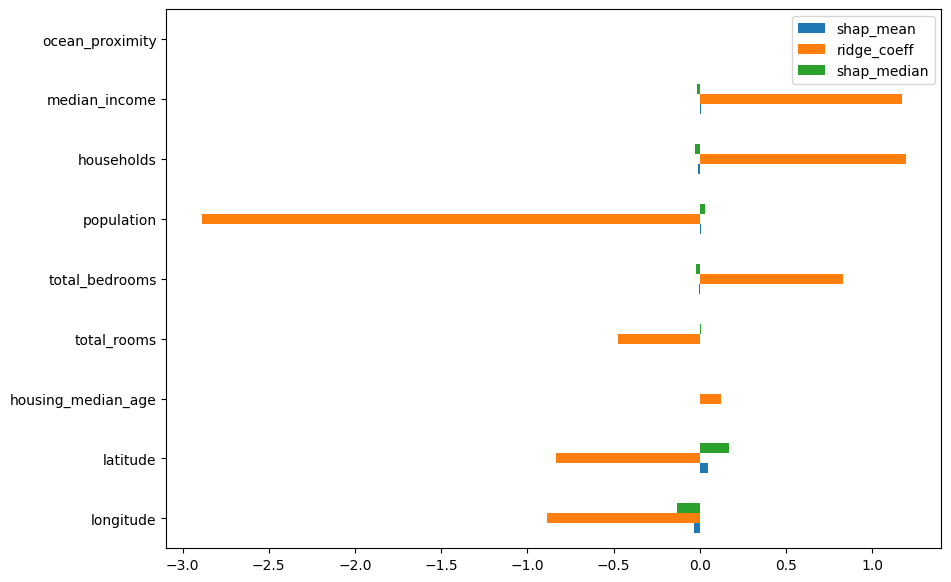

In [120]:

shap_coef_com['shap_median'] = np.median(shap_values_3, axis=0)
shap_coef_com.plot(kind='barh', figsize=(10, 7))

In [113]:
shap_summary_mean['ridge_model'] = mean_shap_values_3
shap_summary_mean

,overfitted_model,not_overfitted_model,best_ensemble_model,ridge_model
longitude,0.000939,0.002975,0.005524,-0.035794
latitude,0.004796,0.004364,0.001924,0.045808
housing_median_age,0.004081,0.002864,0.001298,0.002775
total_rooms,-0.000276,-0.000280,-0.000437,0.003328
total_bedrooms,0.000262,-0.000766,-0.000636,-0.006352
population,0.001082,0.000600,0.001123,0.007152
households,0.000584,0.000272,-0.000066,-0.007934
median_income,-0.006694,-0.007135,-0.006203,0.008892
ocean_proximity,-0.004776,-0.002893,-0.002813,-0.000029


<Axes: >

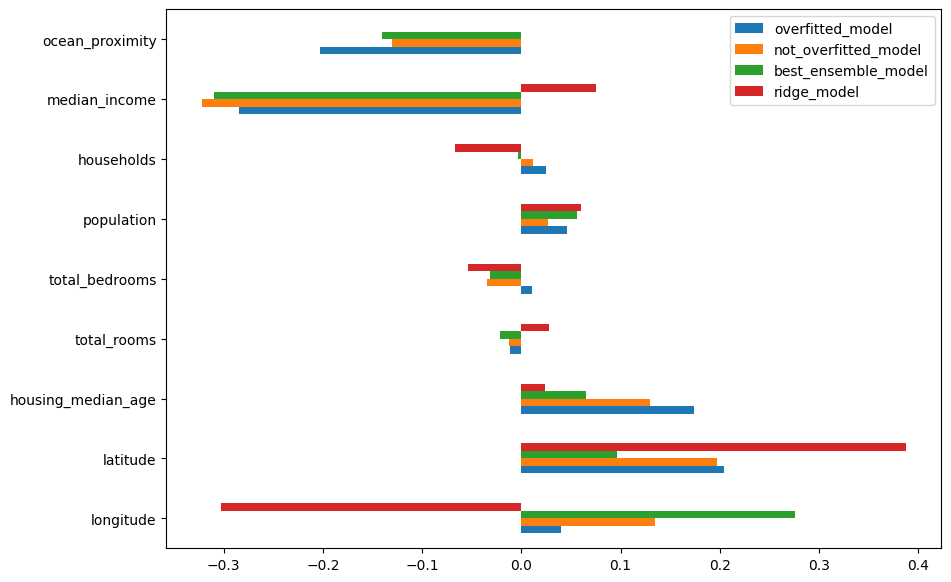

In [115]:
shap_summary_mean.apply(lambda x: x/np.sum(abs(x), axis=0)).plot(kind='barh', figsize=(10, 7))

<Axes: >

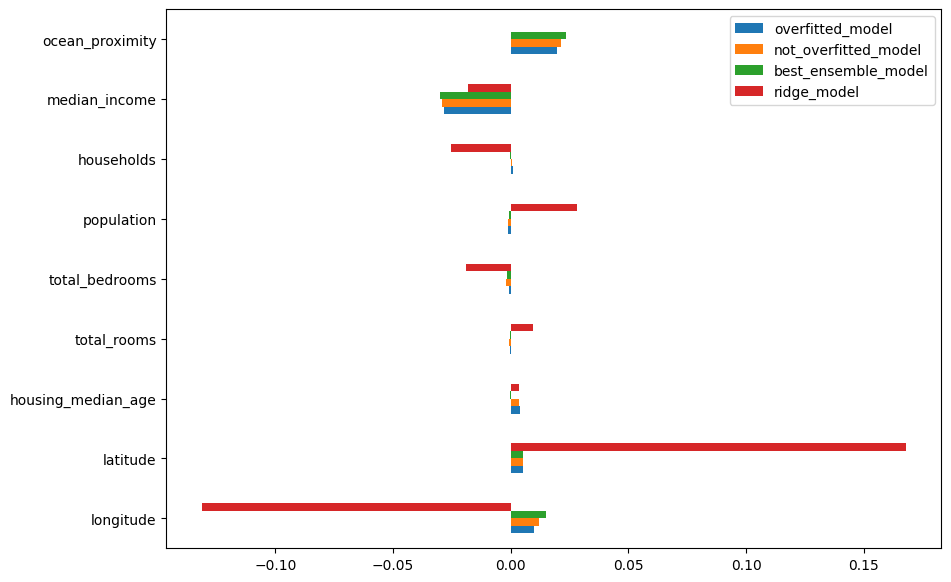

In [117]:
shap_summary_median['ridge_model'] = np.median(shap_values_3, axis=0)
shap_summary_median.plot(kind='barh', figsize=(10, 7))

In [116]:
print(linear_explainer.expected_value)
print(shap_summary_mean.apply(lambda x: sum(x)))

0.3781257951425439
overfitted_model       -4.250073e-16
not_overfitted_model    1.240327e-16
best_ensemble_model    -2.845806e-04
ridge_model             1.784617e-02
dtype: float64


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select only the numerical columns for VIF calculation
X = df[list(set(num_cols) - set(['median_house_value']))]

# Calculate VIF for each column
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns

# Calculate VIF for each feature
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                          for i in range(len(X.columns))]

display(vif_data.sort_values(by='VIF', ascending=False))